In [1]:
from pathlib import Path
import joblib
from insilico_stimuli.stimuli import GaborSet, CenterSurround
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from models.hierarchical_grating_model import HierarchicalGratingModel
from sklearn.metrics.pairwise import cosine_similarity

canvas_size                = [36, 36]
locations                  = [[18, 18]]  # center position
sizes_total                = [36]          # total size (center + surround)
sizes_center               = [0.5]           # portion of radius used for center circle
sizes_surround             = [0.5]      # defines the starting portion of radius for surround
contrasts_center           = [1.0]     # try 2 center contrasts
contrasts_surround         = [1.0]          # surround contrast
orientations_center        = [0.0, np.pi/2, np.pi/4]  # variable orientation
orientations_surround      = [0.0, np.pi/2, np.pi/4]  # center only
spatial_frequencies_center = [0.2]           # fixed spatial frequency
phases_center              = [np.pi]  # center phases 
grey_levels                = [0.0]           # fixed grey level
# spatial_frequencies_surround = [0.1, 0.3]  # optional parameter, default: same as spatial_frequencies_center
# phases_surround = [np.pi/4]                # optional parameter, default: same as phases_center

center_surround = CenterSurround(canvas_size=canvas_size, 
        locations=locations,
        sizes_total=sizes_total,
        sizes_center=sizes_center,
        sizes_surround=sizes_surround,
        contrasts_center=contrasts_center,
        contrasts_surround=contrasts_surround,
        orientations_center=orientations_center,
        orientations_surround=orientations_surround,
        spatial_frequencies_center=spatial_frequencies_center,
        phases_center=phases_center,
        grey_levels=grey_levels
)

# gratings_offset = 0.5
gratings = np.array([center_surround.images()[idx] for idx in range(len(center_surround.images())) if center_surround.params_dict_from_idx(idx)['orientation_center'] == center_surround.params_dict_from_idx(idx)['orientation_surround']])

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
gratings.shape

(3, 36, 36)

In [3]:
first_grating = gratings[0]
second_grating = gratings[1]

In [4]:
cosine_similarity(first_grating.reshape(1, -1), second_grating.reshape(1, -1)).flatten()[0]

0.001001447744584125

In [5]:
offsets = np.linspace(0, 1, 100)
similarities = []
for offset in offsets:
    noised_first = first_grating + offset
    noised_second = second_grating + offset
    similarities.append(cosine_similarity(noised_first.reshape(1, -1), noised_second.reshape(1, -1)).flatten()[0])

Text(0, 0.5, 'Cosine similarity')

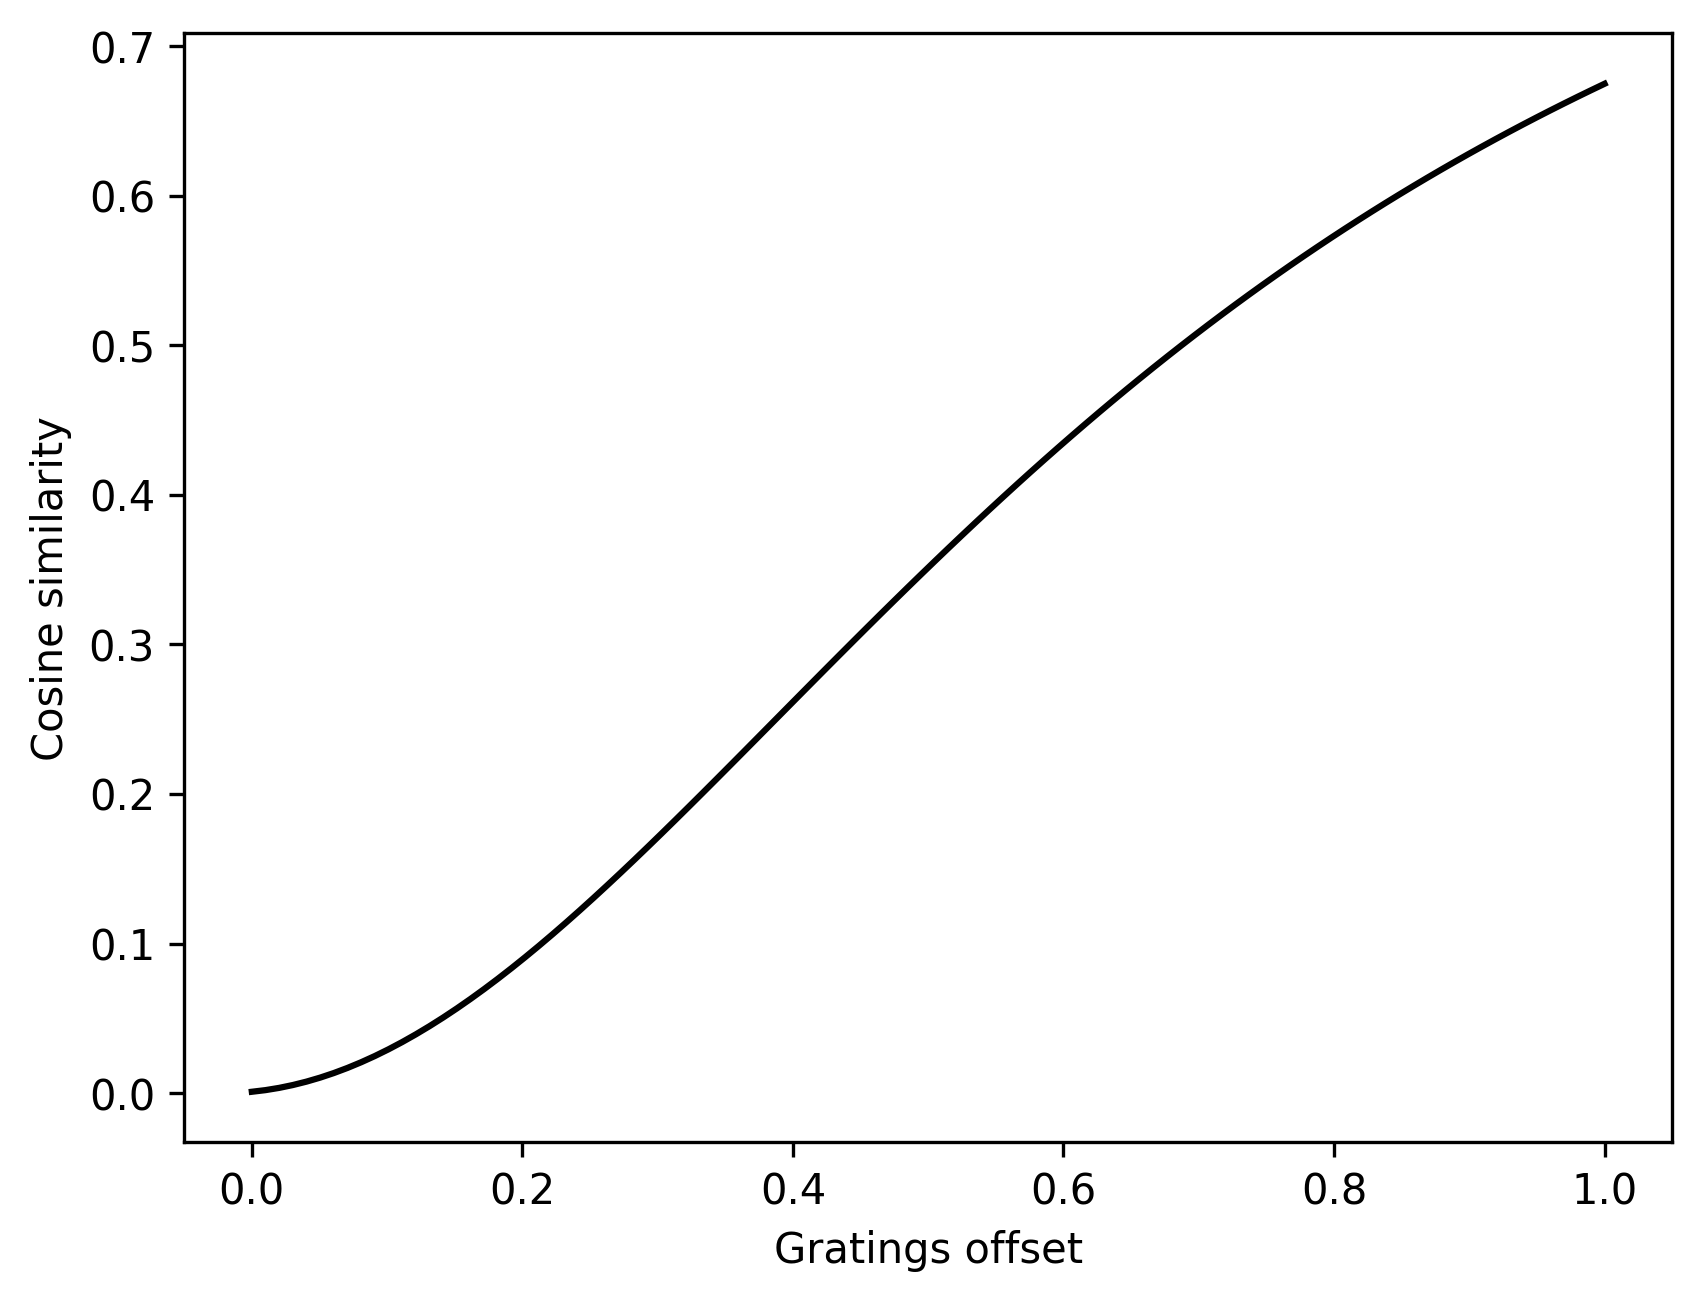

In [6]:
fig, ax = plt.subplots(dpi=300)
ax.plot(offsets, similarities, color="black")
ax.set_xlabel("Gratings offset")
ax.set_ylabel("Cosine similarity")